# Análisis No Supervisado y Clustering con PySpark - Diabetes V1

**Integrantes:** Sebastián, Byron, Jean Daniel.

**Descripción:** Debersito. El objetivo es identificar perfiles ocultos de pacientes diabéticos mediante clustering.

In [1]:
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Inicializar sesión de Spark optimizada para ejecución local
spark = SparkSession.builder     .appName("DiabetesClustering")     .config("spark.driver.memory", "8g")     .getOrCreate()

# Cargar el dataset
file_path = "diabetes_v1_.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)

# Mostrar confirmación de carga
print(f"Dataset cargado con {df.count()} filas y {len(df.columns)} columnas.")

Dataset cargado con 50883 filas y 49 columnas.


root
 |-- encounter_id: integer (nullable = true)
 |-- patient_nbr: integer (nullable = true)
 |-- race: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: string (nullable = true)
 |-- weight: string (nullable = true)
 |-- admission_type_id: integer (nullable = true)
 |-- discharge_disposition_id: integer (nullable = true)
 |-- admission_source_id: integer (nullable = true)
 |-- time_in_hospital: integer (nullable = true)
 |-- payer_code: string (nullable = true)
 |-- medical_specialty: string (nullable = true)
 |-- num_lab_procedures: integer (nullable = true)
 |-- num_procedures: integer (nullable = true)
 |-- num_medications: integer (nullable = true)
 |-- number_outpatient: integer (nullable = true)
 |-- number_emergency: integer (nullable = true)
 |-- number_inpatient: integer (nullable = true)
 |-- diag_1: string (nullable = true)
 |-- diag_2: string (nullable = true)
 |-- diag_3: string (nullable = true)
 |-- number_diagnoses: integer (nullable = true)
 |-

C:\Users\Usuario\AppData\Local\Temp\ipykernel_33512\3864299997.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd_df, x=col, y='count', palette='viridis')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_33512\3864299997.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd_df, x=col, y='count', palette='viridis')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_33512\3864299997.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd_df, x=col, y='count', palette='viridis')


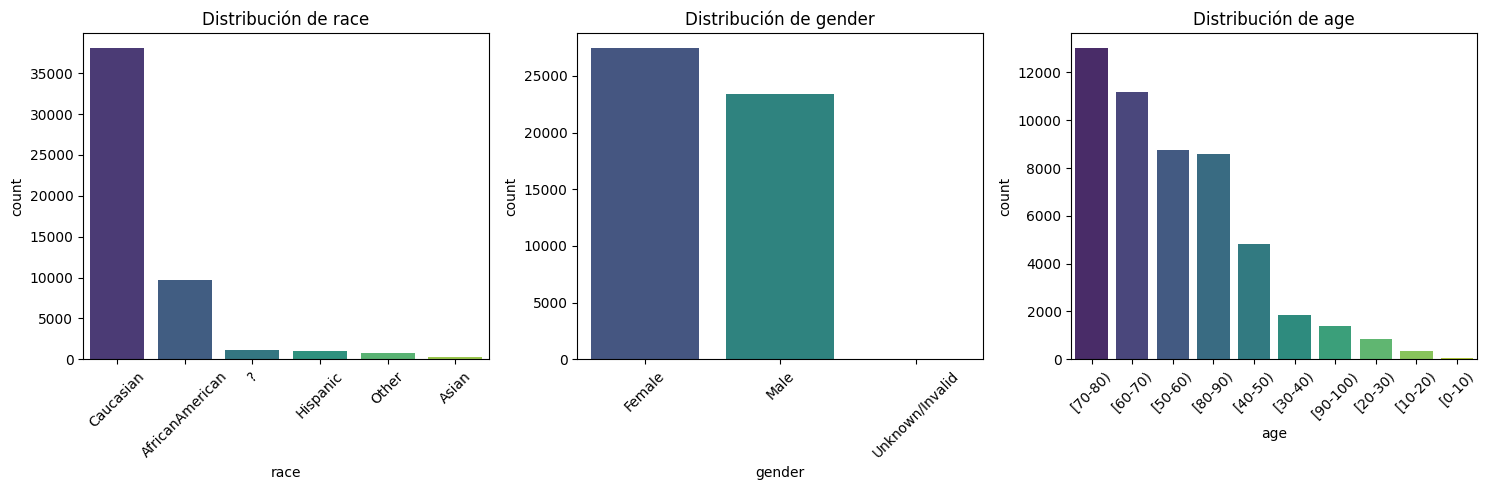

In [2]:
# Esquema del dataset
df.printSchema()

# Análisis de variables categóricas clave
categorical_cols = ['race', 'gender', 'age']

plt.figure(figsize=(15, 5))

for i, col in enumerate(categorical_cols):
    # Agregación en PySpark y paso a Pandas para graficar
    pd_df = df.groupBy(col).count().orderBy("count", ascending=False).toPandas()
    
    plt.subplot(1, 3, i+1)
    sns.barplot(data=pd_df, x=col, y='count', palette='viridis')
    plt.title(f'Distribución de {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

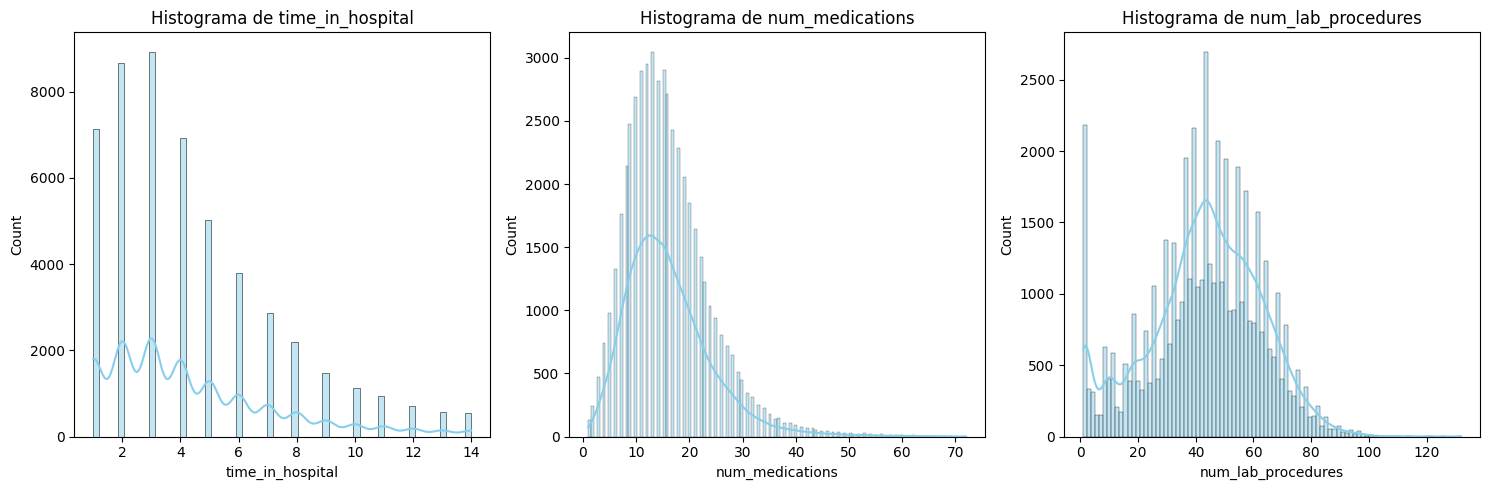

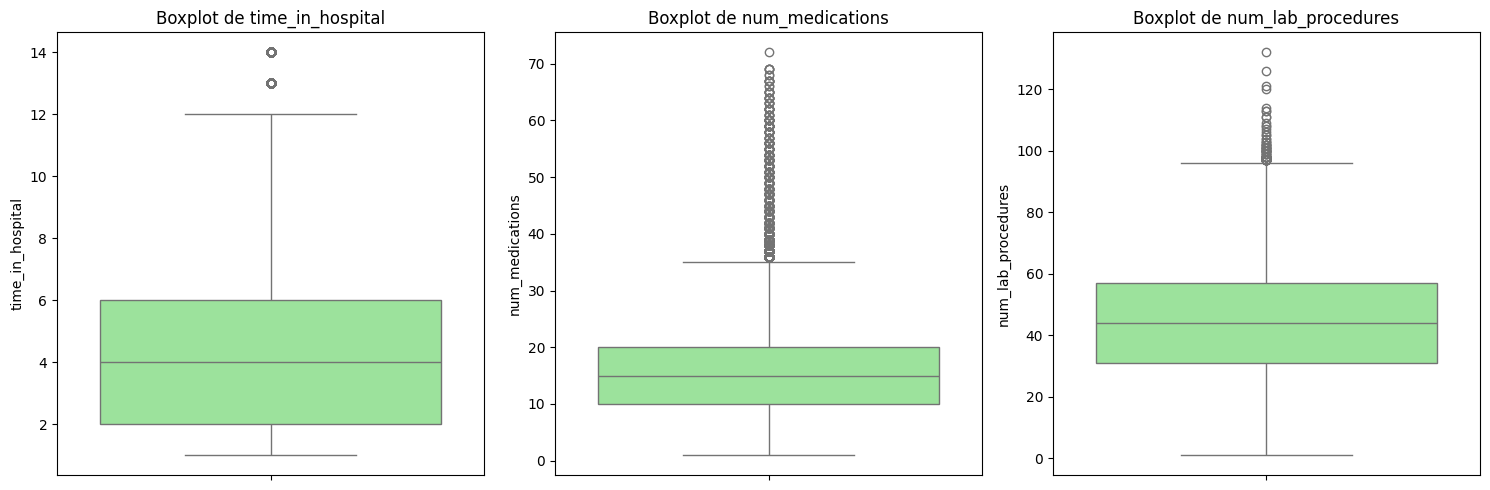

In [3]:
# Análisis de variables numéricas clave
numeric_cols = ['time_in_hospital', 'num_medications', 'num_lab_procedures']

plt.figure(figsize=(15, 5))

for i, col in enumerate(numeric_cols):
    # Seleccionar datos y pasar a Pandas
    pd_series = df.select(col).toPandas()
    
    plt.subplot(1, 3, i+1)
    sns.histplot(pd_series[col], kde=True, color='skyblue')
    plt.title(f'Histograma de {col}')

plt.tight_layout()
plt.show()

# Boxplots para detectar outliers y distribución
plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_cols):
    pd_series = df.select(col).toPandas()
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=pd_series[col], color='lightgreen')
    plt.title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

## Preparación de Datos (Feature Engineering)

Los algoritmos de clustering como **K-Means** calculan distancias euclidianas, por lo que requieren que los datos sean numéricos y estén en la misma escala. 

En este paso realizaremos:
1. **Limpieza:** Manejo de valores faltantes (representados como '?').
2. **Indexación:** Conversión de texto a índices numéricos.
3. **Codificación (OHE):** Creación de variables binarias para categorías.
4. **Vectorización:** Unión de todas las columnas en un solo vector de características.
5. **Escalamiento:** Normalización de los datos.
6. **PCA (Principal Component Analysis):** Reducción de dimensionalidad para mejorar la eficiencia del clustering y mitigar la "maldición de la dimensionalidad" causada por el One-Hot Encoding, mejor dicho bajamos las dimensiones para que sea menos pesado y mas eficiente, viendo los componentes principales

In [4]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler, PCA
from pyspark.sql.functions import when, col

# Limpieza: Reemplazar '?' por None y eliminar filas con nulos en columnas clave
cols_to_clean = ['race', 'gender', 'age']
df_clean = df
for c in cols_to_clean:
    df_clean = df_clean.withColumn(c, when(col(c) == '?', None).otherwise(col(c)))

df_clean = df_clean.dropna(subset=cols_to_clean)

# Definir etapas del Pipeline
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_indexed", handleInvalid="keep") for c in cols_to_clean]
encoders = [OneHotEncoder(inputCol=f"{c}_indexed", outputCol=f"{c}_ohe") for c in cols_to_clean]

# Columnas numéricas a incluir
num_cols = ['time_in_hospital', 'num_medications', 'num_lab_procedures']

# Assembler para crear el vector 'features'
assembler = VectorAssembler(
    inputCols=[f"{c}_ohe" for c in cols_to_clean] + num_cols,
    outputCol="features"
)

# Escalador
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=False)

# Implementación de PCA (Reducción a 10 componentes)
pca = PCA(k=10, inputCol="scaledFeatures", outputCol="pcaFeatures")

# Crear y ejecutar el Pipeline incluyendo PCA
pipeline = Pipeline(stages=indexers + encoders + [assembler, scaler, pca])
model_pipeline = pipeline.fit(df_clean)
dataset_final = model_pipeline.transform(df_clean)

# Mostrar resultado del procesamiento
dataset_final.select("features", "scaledFeatures", "pcaFeatures").show(5, truncate=False)

+---------------------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features                                           |scaledFeatures                                                                                                                         |pcaFeatures                                                                                                                                                                                                |
+---------------------------------------------------+---------------------------------------------------------------------------------------------------------------------------------------+-----------------------

Evaluando diferentes valores de K...
K=2 | Silhouette Score = 0.2717
K=3 | Silhouette Score = 0.2555
K=4 | Silhouette Score = 0.2501
K=5 | Silhouette Score = 0.3346
K=6 | Silhouette Score = 0.3436


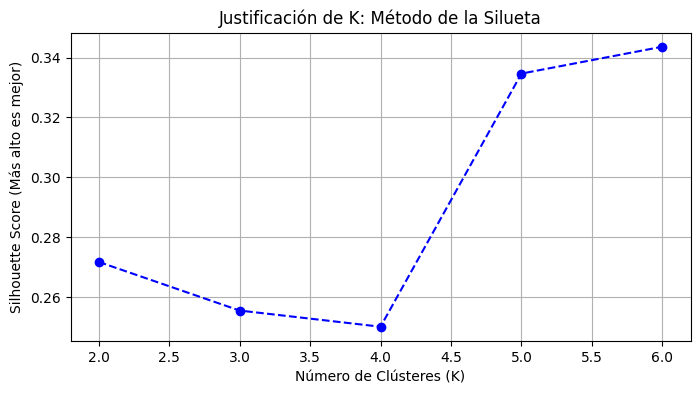

In [5]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt

silhouette_scores = []
k_values = range(2, 7) # Probaremos con 2, 3, 4, 5 y 6 clústeres

evaluator = ClusteringEvaluator(predictionCol="prediction", featuresCol="pcaFeatures", metricName="silhouette")

print("Evaluando diferentes valores de K...")
for k in k_values:
    # Usamos pcaFeatures en lugar de scaledFeatures
    kmeans_temp = KMeans(featuresCol="pcaFeatures", predictionCol="prediction", k=k, seed=42)
    model_temp = kmeans_temp.fit(dataset_final)
    predictions_temp = model_temp.transform(dataset_final)
    
    score = evaluator.evaluate(predictions_temp)
    silhouette_scores.append(score)
    print(f"K={k} | Silhouette Score = {score:.4f}")

# Graficar para justificar visualmente
plt.figure(figsize=(8, 4))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='--', color='b')
plt.title('Justificación de K: Método de la Silueta')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Silhouette Score (Más alto es mejor)')
plt.grid(True)
plt.show()

In [6]:
from pyspark.ml.clustering import KMeans

# Entrenar K-Means definitivo basándose en el mejor valor de la gráfica anterior
mejor_k = 3 # Basado en la evaluación previa
kmeans = KMeans(featuresCol="pcaFeatures", predictionCol="prediction", k=mejor_k, seed=42)
model = kmeans.fit(dataset_final)

# Obtener predicciones
predictions = model.transform(dataset_final)

print(f"Entrenamiento completado. {mejor_k} Clústeres asignados usando PCA.")

Entrenamiento completado. 3 Clústeres asignados usando PCA.


In [7]:
from pyspark.ml.evaluation import ClusteringEvaluator

# Evaluar el modelo final usando el Coeficiente de Silueta sobre pcaFeatures
evaluator = ClusteringEvaluator(predictionCol="prediction", featuresCol="pcaFeatures", metricName="silhouette")

silhouette = evaluator.evaluate(predictions)

print("-" * 30)
print(f"📊 Coeficiente de Silueta Final: {silhouette:.4f}")
print("-" * 30)

------------------------------
📊 Coeficiente de Silueta Final: 0.2555
------------------------------


In [8]:
# Análisis de los perfiles clínicos por clúster
print("Resumen estadístico por Clúster:")
perfiles = predictions.groupBy("prediction") \
    .agg({
        "time_in_hospital": "mean", 
        "num_medications": "mean",
        "num_lab_procedures": "mean"
    }) \
    .orderBy("prediction")

perfiles.show()

# Interpretación textual breve basada en los resultados
print("Interpretación de los Clústeres:")
print("- Clúster 0: Posible perfil de baja intensidad clínica.")
print("- Clúster 1: Pacientes con mayor estancia o medicación.")
print("- Clúster 2: Perfil intermedio o con alta frecuencia de laboratorios.")

Resumen estadístico por Clúster:
+----------+--------------------+-----------------------+---------------------+
|prediction|avg(num_medications)|avg(num_lab_procedures)|avg(time_in_hospital)|
+----------+--------------------+-----------------------+---------------------+
|         0|  16.026725565985643|     42.660132523467695|    4.238266151297625|
|         1|  15.268042996075755|      43.87340044361031|    4.431155092987545|
|         2|   16.46379795139586|     42.844346254267926|    4.473990761197028|
+----------+--------------------+-----------------------+---------------------+

Interpretación de los Clústeres:
- Clúster 0: Posible perfil de baja intensidad clínica.
- Clúster 1: Pacientes con mayor estancia o medicación.
- Clúster 2: Perfil intermedio o con alta frecuencia de laboratorios.
